In [10]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from arch import arch_model

In [11]:
data = pd.read_csv("../data/features_target.csv")

data['Unnamed: 0'] = pd.to_datetime(data['Unnamed: 0'])
data.rename(columns = {'Unnamed: 0':'Date'}, inplace=True) 
data.set_index('Date', inplace = True)

returns = 100 * data['SP500'].pct_change().dropna()
returns = returns.drop(returns[returns == 0].index)

vol = returns.rolling(window = 30, min_periods = 30).std().dropna()

In [12]:
split_date = '2018-01-01'

train = vol[vol.index < split_date].copy()
test = vol[vol.index >= split_date].copy()

In [13]:
garch = arch_model(train, dist="ged", vol = 'GARCH', p=1, q=1)
garch_fit = garch.fit(disp='off')
garch_fit.summary()

/home/aseliverstov/projects/EconometricVolatilityST/.venv/lib/python3.12/site-packages/arch/univariate/distribution.py:1142: RuntimeWarning: overflow encountered in power
  lls -= 0.5 * abs(resids / (sqrt(sigma2) * c)) ** nu


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Constant Mean - GARCH Model Results                            
==========================================================================================
Dep. Variable:                              SP500   R-squared:                       0.000
Mean Model:                         Constant Mean   Adj. R-squared:                  0.000
Vol Model:                                  GARCH   Log-Likelihood:                883.267
Distribution:      Generalized Error Distribution   AIC:                          -1756.53
Method:                        Maximum Likelihood   BIC:                          -1729.05
                                                    No. Observations:                 1804
Date:                            Tue, Apr 21 2026   Df Residuals:                     1803
Time:                                    23:21:05   Df Model:                            1
                               Mean Model                               
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.7115  1.569e-02     45.358      0.000 [  0.681,  0.742]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega      3.5327e-03  4.908e-04      7.198  6.108e-13  [2.571e-03,4.495e-03]
alpha[1]       0.5798  2.539e-02     22.838 1.907e-115      [  0.530,  0.630]
beta[1]    1.7803e-10  2.587e-02  6.882e-09      1.000 [-5.070e-02,5.070e-02]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             5.9481      0.449     13.261  3.881e-40 [  5.069,  6.827]
========================================================================

Covariance estimator: robust
"""

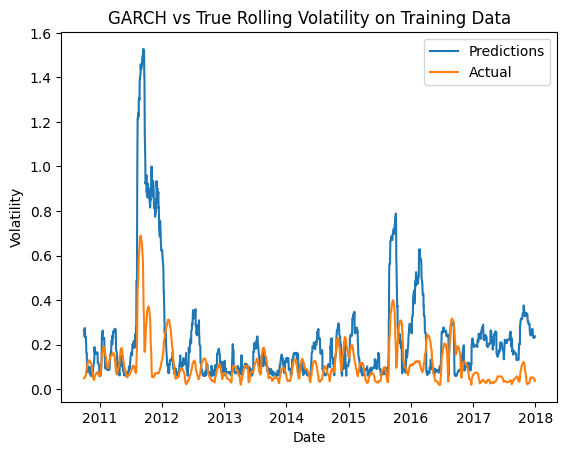

In [14]:
rvol = abs(train.rolling(window=30, min_periods=30).std().dropna())

combined = pd.concat([pd.DataFrame(garch_fit.conditional_volatility), rvol.dropna()], axis=1).dropna()

plt.plot(combined)
plt.title('GARCH vs True Rolling Volatility on Training Data')
plt.legend(['Predictions', 'Actual'])
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

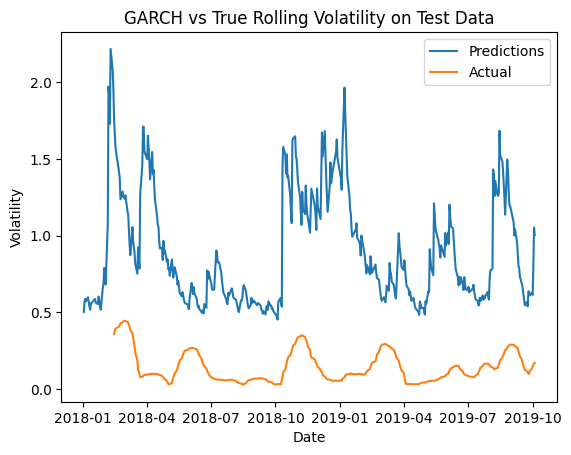

In [15]:
tsize = len(test)
preds = []
for i in range(tsize):
    train = returns[:(i-tsize)]
    garch = arch_model(train, dist = "ged", vol = 'GARCH', p=1, q=1)
    garch_fit = garch.fit(disp = 'off')
    pred = garch_fit.forecast(horizon=1, reindex = False)
    preds.append(np.sqrt(pred.variance.values[-1,:][0]))
    
preds = pd.Series(preds, returns.dropna().index[-tsize:])
predicted = plt.plot(preds)
rvol = abs(test.rolling(window=30, min_periods=30).std().dropna())
real = plt.plot(rvol)
plt.title('GARCH vs True Rolling Volatility on Test Data')
plt.legend(['Predictions', 'Actual'])
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.show()

In [16]:
preds = preds[29:]
mse = mean_squared_error(rvol, preds)
rmse = math.sqrt(mse)
print("Mean Squared Error for our Predictions: " + str(mse))
print("Root Mean Squared Error for our Predictions: " + str(rmse))

Mean Squared Error for our Predictions: 0.6741216842162708
Root Mean Squared Error for our Predictions: 0.8210491362983526
